# Training Intermediate NN

In [4]:
#########################     LIBRARIES     ##########################
from keras.models import Model
from keras.layers import Dense, Input
#from keras.layers.merge import concatenate
from tensorflow.keras.layers import concatenate     # PROBLEMA SEMBRA RISOLTO COSI !!!
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from math import pi
from keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossValGP, transfBestparam
from time import perf_counter

seed = 7
np.random.seed(seed)

In [5]:
start = perf_counter()



########################     PREPARATION      ##########################
HF_data = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/HF_num_data.txt").astype(int) #list of number of HF data
Nlf_models = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/N_bases.txt").astype(int)   #list of number of bases
HF_data_str = [str(num) for num in HF_data]
U_lf_train_full = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/Ulf_train_young.txt")

n_bases = U_lf_train_full.shape[1]   
m = list(Nlf_models).index(n_bases)
n_HF = 15
n_HF_txt = str(n_HF) + '.txt'

In [8]:
#########################     TRAIN SET      ##########################
mu_train_LF = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/mu_train_LF_young.txt")[:,0]
Nlf = np.size(mu_train_LF)  #number of low-fidelity data to TRAIN the NN

U_lf_train = U_lf_train_full[:,m]

mu_train_HF = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/mu_train_HF_young_" + n_HF_txt)[:,0]
Nhf = np.size(mu_train_HF)  # number of high-fidelity data to TRAIN the NN

U_hf_train = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/Uhf_train_young_" + n_HF_txt)

Nepo = 1000
N = Nhf + Nlf

In [10]:
#########################     TEST SET      ##########################
mu_test = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/mu_test_young.txt")[:,0]
N_test = np.size(mu_test)

U_lf_test_full = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/Ulf_test_young.txt")
U_lf_test = U_lf_test_full[:,m]

U_hf_test = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/Uhf_test_young.txt")

In [11]:
########################     NORMALIZATION  #########################
#Input
mu_max = np.max(mu_test)
mu_min = np.min(mu_test)

mu_test_norm = (mu_test - mu_min) / (mu_max - mu_min)
mu_train_LF_norm = (mu_train_LF - mu_min) / (mu_max - mu_min)
mu_train_HF_norm = (mu_train_HF - mu_min) / (mu_max - mu_min)

#Output
# TRANSFORMATION     # 
# in order to reduce the linear relationship between the Young modulus and the displacement
U_lf_train = np.exp(U_lf_train*100)*1e-6
U_lf_test = np.exp(U_lf_test*100)*1e-6
U_hf_train = np.exp(U_hf_train*100)*1e-6
U_hf_test = np.exp(U_hf_test*100)*1e-6
#
lfmean = np.mean(U_lf_test)
hfmean = np.mean(U_hf_test)

U_lf_train = U_lf_train - lfmean
U_lf_test = U_lf_test - lfmean
U_hf_train = U_hf_train - hfmean
U_hf_test = U_hf_test - hfmean

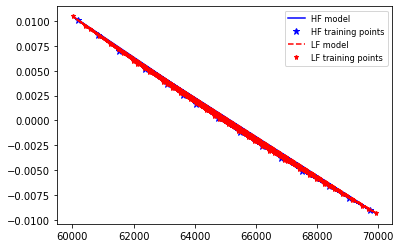

In [12]:
##################     Print LF and HF models      ###################
plt.figure()
plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(mu_test, U_lf_test,'r--', linewidth = 1.5, label = 'LF model')
plt.plot(mu_train_LF, U_lf_train,'r*', markersize = 5, label = 'LF training points')
plt.legend(loc = 1, prop={'size':8.3})
plt.show()

## Training

In [13]:
####################    HYPERPARAMETER OPTIMIZATION    #######################
K.clear_session()
name = 'Inter'

MAX_EVAL = 10

bayes_trials = Trials()
opt_list = ['Adam','Adamax','standardadam']
kernel_list = ['uniform','glorot_uniform']
aux_dic = {'opt': opt_list, 'kernel_init': kernel_list}
space = {
    'alpha' : hp.loguniform('alpha',np.log(0.0001),np.log(0.1)),
    'nodes' : hp.qloguniform('nodes',np.log(4),np.log(128),2),
    'epochs': hp.quniform('epochs',1,5,1), #I put 5 instead of 3
    'l2weight' : hp.loguniform('l2weight',np.log(0.0001),np.log(1)),
    'lr': hp.loguniform('lr',np.log(0.0001),np.log(0.1)),
    'kernel_init': hp.choice('kernel_init',kernel_list),
    'opt' : hp.choice('opt',opt_list)}

def objective(params):
    K.clear_session()
    CVres = kCrossValGP(Nhf,Nlf,Nepo,mu_train_HF_norm,U_hf_train,mu_train_LF_norm,U_lf_train,params,name)
    return {'loss' : CVres, 'params':params, 'status': STATUS_OK}

best_params = fmin(fn = objective,
                   space = space,
                   algo = tpe.suggest,
                   max_evals = MAX_EVAL,
                   trials = bayes_trials)

transfBestparam(best_params,aux_dic)
print(best_params)

1/1 [==============================] - 0s 177ms/step 

1/1 [==============================] - 0s 35ms/step  

1/1 [==============================] - 0s 32ms/step  

1/1 [==============================] - 0s 31ms/step  

1/1 [==============================] - 0s 23ms/step  

1/1 [==============================] - 0s 43ms/step  

  0%|          | 0/10 [02:33<?, ?trial/s, best loss=?]


KeyboardInterrupt: 

In [ ]:
####################    NN training and PREDICTION    #######################
mu_train_norm = np.concatenate((mu_train_HF_norm, mu_train_LF_norm))

finalModel = getModel(best_params,name)
hist = finalModel.fit(mu_train_norm, np.concatenate((U_hf_train, U_lf_train)),validation_data=(mu_test_norm,[U_hf_test, U_lf_test]), epochs=Nepo * int(best_params['epochs']),batch_size=N, verbose = 0, validation_freq = 50)

U_pred = finalModel.predict(mu_test_norm)

stop = perf_counter()
elapsed = stop - start
print('Elapsed time: ', elapsed)

U_Pred = np.concatenate((U_pred[0],U_pred[1]))
U_test = np.concatenate((U_hf_test,U_lf_test))

test_mse = np.mean(np.square(U_test- U_Pred[:,0]))
print(f"Test MSE: {test_mse}")

r_2 = 1 - np.sum(np.square(U_test - U_Pred[:,0])) / np.sum(np.square(U_test - np.mean(U_test)))
print(f"R^2: {r_2}")

print('Number of basis functions: ', int(Nlf_models[m]))

print('Number of base functions: ', int(Nlf_models[m]))
print('Number of HF data: ', n_HF)

In [ ]:
####################     PLOTS    #######################
plt.figure(figsize = [12,7])
plt.subplot(2,1,1)
plt.plot(mu_test ,U_pred[0],'k', label = 'estimated $U_{HF}$')
plt.plot(mu_train_HF ,U_hf_train ,'ro', label = 'HF data',markersize = 4)
plt.plot(mu_test, U_hf_test ,'--k', label = 'exact solution')
plt.title('High fidelity model ')
plt.legend(loc = 0,prop={'size': 8.3})
plt.subplot(2,1,2)
plt.plot(mu_test,U_pred[1],'k', label = 'estimated $U_{LF}$')
plt.plot(mu_train_LF,U_lf_train,'ro', label = 'LF data',markersize = 4)
plt.plot(mu_test,U_lf_test,'--k', label = 'exact solution')
plt.title('Low fidelity model')
plt.legend(loc = 0,prop={'size': 8.3})

In [ ]:
####################    TRAINING INSIGHTS    #######################
plt.figure()
plt.subplot(2,1,1)
plt.plot(hist.history['HF_loss'],color='red',label='High fidelity train mse')
plt.plot(hist.history['LF_loss'],color='black',label='Low fidelity')
plt.legend()
plt.yscale('log')
plt.subplot(2,1,2)
plt.plot(hist.history['val_HF_loss'],color='red')
plt.plot(hist.history['val_LF_loss'],color='black')
plt.yscale('log')